## What does the dataset look like?

In [1]:
import matplotlib.pyplot as plt
import xarray as xr


ds = xr.open_dataset("../scripts/dataset/earthcare_06346D_GLM_22.h5")
ds

<xarray.Dataset> Size: 5MB
Dimensions:                                 (along_track: 256, height: 200)
Coordinates:
  * along_track                             (along_track) int64 2kB 3696 ... ...
    time                                    (along_track) datetime64[ns] 2kB ...
    latitude                                (along_track) float64 2kB ...
    longitude                               (along_track) float64 2kB ...
  * height                                  (height) float64 2kB 50.0 ... 1.9...
Data variables: (12/22)
    lightning_count_2p5                     (along_track) uint32 1kB ...
    lightning_count_5                       (along_track) uint32 1kB ...
    ice_water_content                       (along_track, height) float32 205kB ...
    ice_mass_flux                           (along_track, height) float32 205kB ...
    ice_effective_radius                    (along_track, height) float32 205kB ...
    ice_median_volume_diameter              (along_track, height) float32 205kB ...
    ...                                      ...
    sedimentation_velocity_best_estimate    (along_track, height) float32 205kB ...
    spectrum_width_integrated               (along_track, height) float32 205kB ...
    reflectivity_no_attenuation_correction  (along_track, height) float32 205kB ...
    reflectivity_corrected                  (along_track, height) float32 205kB ...
    multiple_scattering_status              (along_track, height) float64 410kB ...
    simplified_convective_classification    (along_track, height) float64 410kB ...

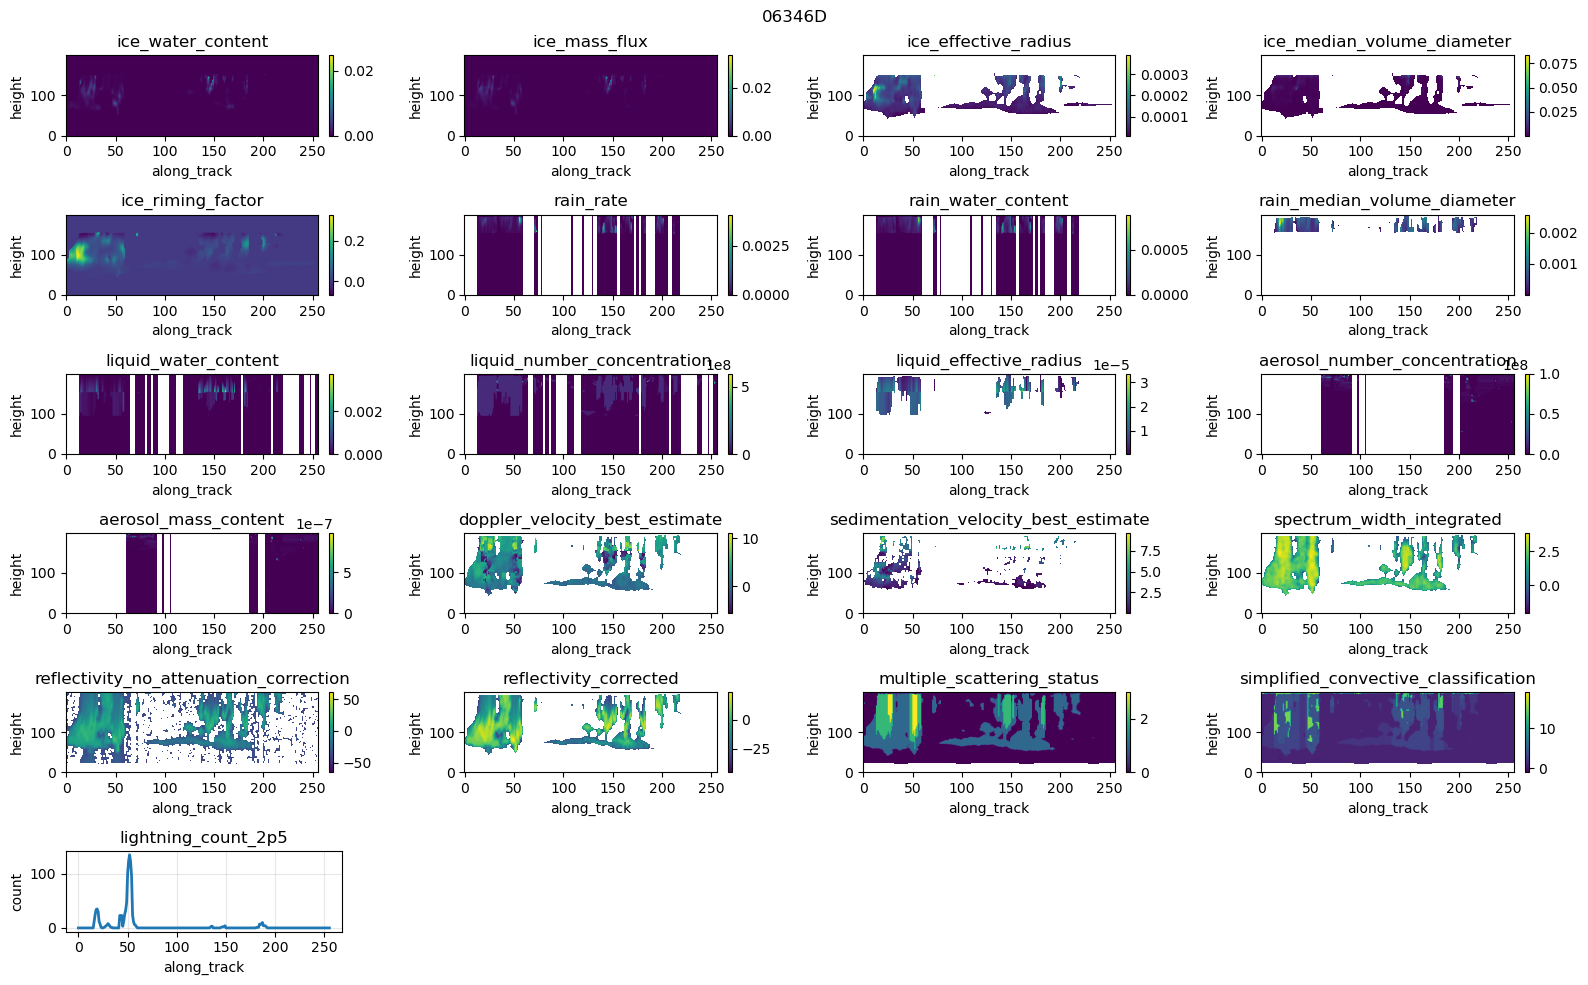

In [13]:

INPUT_VARS = [
    "ice_water_content",
    "ice_mass_flux",
    "ice_effective_radius",
    "ice_median_volume_diameter",
    "ice_riming_factor",
    "rain_rate",
    "rain_water_content",
    "rain_median_volume_diameter",
    "liquid_water_content",
    "liquid_number_concentration",
    "liquid_effective_radius",
    "aerosol_number_concentration",
    "aerosol_mass_content",
    "doppler_velocity_best_estimate",
    "sedimentation_velocity_best_estimate",
    "spectrum_width_integrated",
    "reflectivity_no_attenuation_correction",
    "reflectivity_corrected",
    "multiple_scattering_status",
    "simplified_convective_classification",
]

TARGET_VARS = [
    "lightning_count_2p5",
    "lightning_count_5",
]
import xarray as xr
import matplotlib.pyplot as plt

def plot_one_patch(
    ds,
    input_vars,
    target_var="lightning_count_2p5",
    n_inputs=20,
    figsize=(16, 10),
):
    

    try:
        vars_to_plot = input_vars[:n_inputs]

        ncols = 4
        nrows = (len(vars_to_plot) + 1 + ncols - 1) // ncols  # +1 for target plot

        fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
        axes = axes.flatten()

       
        for i, var in enumerate(vars_to_plot):
            arr = ds[var].transpose("height", "along_track").values

            im = axes[i].imshow(
                arr,
                aspect="auto",
                origin="lower",
            )
            axes[i].set_title(var)
            axes[i].set_xlabel("along_track")
            axes[i].set_ylabel("height")
            plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

        # plot target profile
        y = ds[target_var].values
        ax_t = axes[len(vars_to_plot)]
        ax_t.plot(y, linewidth=2)
        ax_t.set_title(target_var)
        ax_t.set_xlabel("along_track")
        ax_t.set_ylabel("count")
        ax_t.grid(True, alpha=0.3)

        # hide unused axes
        for j in range(len(vars_to_plot) + 1, len(axes)):
            axes[j].axis("off")

        fig.suptitle('06346D', fontsize=12)
        plt.tight_layout()
        plt.show()

    finally:
        ds.close()

plot_one_patch(
    ds,
    input_vars=INPUT_VARS,
    target_var="lightning_count_2p5",
    n_inputs=20,
)

In [17]:
ds.simplified_convective_classification

<xarray.DataArray 'simplified_convective_classification' (along_track: 256,
                                                          height: 200)> Size: 410kB
[51200 values with dtype=float64]
Coordinates:
  * along_track  (along_track) int64 2kB 3696 3697 3698 3699 ... 3949 3950 3951
    time         (along_track) datetime64[ns] 2kB ...
    latitude     (along_track) float64 2kB ...
    longitude    (along_track) float64 2kB ...
  * height       (height) float64 2kB 50.0 150.0 250.0 ... 1.985e+04 1.995e+04
Attributes:
    long_name:   Simplified convective classification
    definition:  -1 = No data, 0 = Ground and underground levels, 1 = Clear, ...

In [18]:
ds.multiple_scattering_status

<xarray.DataArray 'multiple_scattering_status' (along_track: 256, height: 200)> Size: 410kB
[51200 values with dtype=float64]
Coordinates:
  * along_track  (along_track) int64 2kB 3696 3697 3698 3699 ... 3949 3950 3951
    time         (along_track) datetime64[ns] 2kB ...
    latitude     (along_track) float64 2kB ...
    longitude    (along_track) float64 2kB ...
  * height       (height) float64 2kB 50.0 150.0 250.0 ... 1.985e+04 1.995e+04
Attributes:
    long_name:   Multiple scattering status
    definition:  0 = Undetermined, 1 = Single scattering, 2 = Moderate multip...

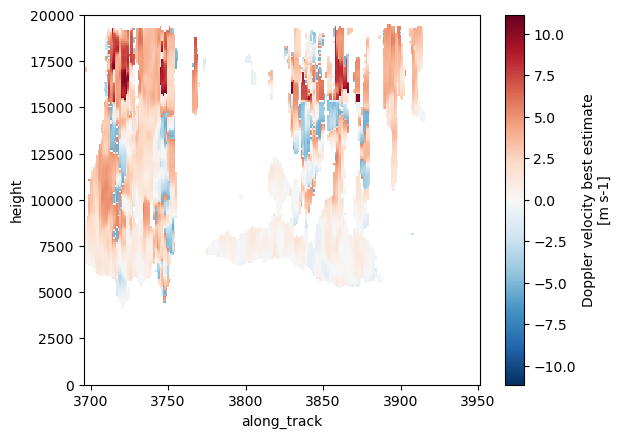

In [4]:
ds.doppler_velocity_best_estimate.T.plot()

# Study day/night frames

### Split day night

In [11]:
import os
from pathlib import Path

def separate_day_night_files(dataset_path):

    dataset_path = Path(dataset_path)
    all_files = sorted(str(f) for f in dataset_path.iterdir() if f.suffix == ".h5")

    night_files, day_files = [], []

    for file in all_files:
        
        if file.split('_')[-3][-1] in ['A','B','H']:
            night_files.append(file)
        else:
            day_files.append(file)
    return night_files, day_files


dataset_dir = 'earthcare_patches'

nf, df = separate_day_night_files(dataset_dir)

# print(df, nf)



In [12]:
len(df)

725

## Categorical Variables

In [19]:
import re

def parse_definition(definition_str):
    matches = re.findall(r'(-?\d+)\s*=\s*([^,]+)', definition_str)
    return {int(k): v.strip() for k, v in matches}

In [3]:
"""
definition :
    -1 = No data, 0 = Ground and underground levels, 1 = Clear, 2 = Weak convective and stratiform clouds, 
    3 = Deep convective clouds, 4 = Dynamic convective cores, 5 = Uncertain, 12 = Heavy rain likely present,  
    13 = Heavy mixed-phase precipitation likely present,  14 = Heavy rain,  15 = Heavy mixed-phase precipitation,  
    16 = Removed ground clutter, possible drizzle/rain in clutter, 
    17 = Removed ground clutter, possible snow/mixed-phase precip in clutter,  18 = Removed ground clutter, possible cloud in clutter,  
    19 = Removed ground clutter, cloud/precip unlikely present in this layer
"""

SCC_CLASS_MAP = {
    0: "Ground and underground levels",
    1: "Clear",
    2: "Weak conv./strat.",
    3: "Deep conv. clouds",
    4: "Dynamic conv. cores",
    5: "Uncertain",
    12: "Heavy rain likely",
    13: "Heavy mixed-phase precip. likely",
    14: "Heavy rain",
    15: "Heavy mixed-phase precip",
    16: "Removed ground clutter, possible drizzle/rain in clutter",
    17: "Removed ground clutter, possible snow/mixed-phase precip in clutter",
    18: "Removed ground clutter, possible cloud in clutter",
    19: "Removed ground clutter, cloud/precip unlikely present in this layer"
}

"""
0 = Undetermined, 1 = Single scattering, 2 = Moderate multiple scattering, 3 = Strong multiple scattering
"""

MSS_CLASS_MAP = {
    0: "Undetermined",
    1: "Single scattering",
    2: "Moderate multiple scattering",
    3: "Strong multiple scattering",
}




In [16]:
import numpy as np
import xarray as xr

def compute_class_height_probabilities(
    file_paths,
    var_name,
    class_map,
    exclude_values=None
):
   
    class_values = list(class_map.keys())
    class_to_idx = {c: i for i, c in enumerate(class_values)}

    
    with xr.open_dataset(file_paths[0]) as ds0:
        heights = ds0["height"].values.astype(float)

    step = 100.0
    height_bin_edges = np.concatenate([
        [heights[0] - step / 2],
        0.5 * (heights[:-1] + heights[1:]),
        [heights[-1] + step / 2],
    ])

    height_bin_edges = np.asarray(height_bin_edges)
    n_bins = len(height_bin_edges) - 1
    n_classes = len(class_values)

    counts = np.zeros((n_classes, n_bins), dtype=np.int64)
    totals = np.zeros(n_bins, dtype=np.int64)

    exclude_values = set([] if exclude_values is None else exclude_values)

    for file_path in file_paths:
        ds = xr.open_dataset(file_path)
        try:
            arr = ds[var_name].transpose("along_track", "height").values
            h = ds["height"].values.astype(float)

           
            h_bin_idx = np.digitize(h, height_bin_edges) - 1

            for j in range(arr.shape[1]): 
                b = h_bin_idx[j]
                if b < 0 or b >= n_bins:
                    continue

                vals = arr[:, j]
                valid = np.isfinite(vals)

                if exclude_values:
                    valid &= ~np.isin(vals, list(exclude_values))

                vals = vals[valid].astype(int)

                if vals.size == 0:
                    continue

                totals[b] += vals.size

                for v in vals:
                    if v in class_to_idx:
                        counts[class_to_idx[v], b] += 1

        finally:
            ds.close()

    probs = counts / np.maximum(totals[None, :], 1)
    bin_centers = 0.5 * (height_bin_edges[:-1] + height_bin_edges[1:])

    return probs, counts, totals, bin_centers, class_values

day_probs, day_counts, day_totals, day_bin_centers, day_class_values = compute_class_height_probabilities(
    df,
    "simplified_convective_classification",
    SCC_CLASS_MAP
)
night_probs, night_counts, night_totals, night_bin_centers, night_class_values = compute_class_height_probabilities(
    nf,
    "simplified_convective_classification",
    SCC_CLASS_MAP
)
daynight_stats = {
    "day":{
        "probs": day_probs,
        "counts": day_counts,
        "totals": day_totals,
        "bin_centers": day_bin_centers,
        "class_values": day_class_values
            },
    "night":{
        "probs": night_probs,
        "counts": night_counts,
        "totals": night_totals,
        "bin_centers": night_bin_centers,
        "class_values": night_class_values
            }
}



In [17]:
import matplotlib.pyplot as plt

def plot_class_height_heatmap(
    probs,
    class_values,
    bin_centers,
    class_map,
    title,
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
    save_dir=None
):
    fig, ax = plt.subplots(figsize=(10, 10))

    im = ax.imshow(
        probs.T,   # x = class, y = height
        aspect="auto",
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        extent=[
            -0.5,
            len(class_values) - 0.5,
            bin_centers[0] / 1000,
            bin_centers[-1] / 1000,
        ],
    )

    ax.set_title(title)
    ax.set_xlabel("Class")
    ax.set_ylabel("Height [km]")

    ax.set_xticks(np.arange(len(class_values)))
    ax.set_xticklabels(
        [f"{c}: {class_map[c]}" for c in class_values],
        rotation=90,
        ha="right"
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("P(class | height bin)")

    plt.tight_layout()
    if save_dir is None:
        plt.show()
    else:
        plt.savefig(save_dir)
        plt.close()
    

plot_class_height_heatmap(
    probs = daynight_stats["day"]["probs"],
    class_values = daynight_stats["day"]["class_values"],
    bin_centers = daynight_stats["day"]["bin_centers"],
    class_map = SCC_CLASS_MAP,
    title="Day: simplified convective classification",
    save_dir = "stats_plots/day_simplified_convective_classification_hm.png"
)

plot_class_height_heatmap(
    daynight_stats["night"]["probs"],
    daynight_stats["night"]["class_values"],
    daynight_stats["night"]["bin_centers"],
    SCC_CLASS_MAP,
    title="Night: simplified convective classification",
    save_dir = "stats_plots/night_simplified_convective_classification_hm.png"
)

### Compare day/night

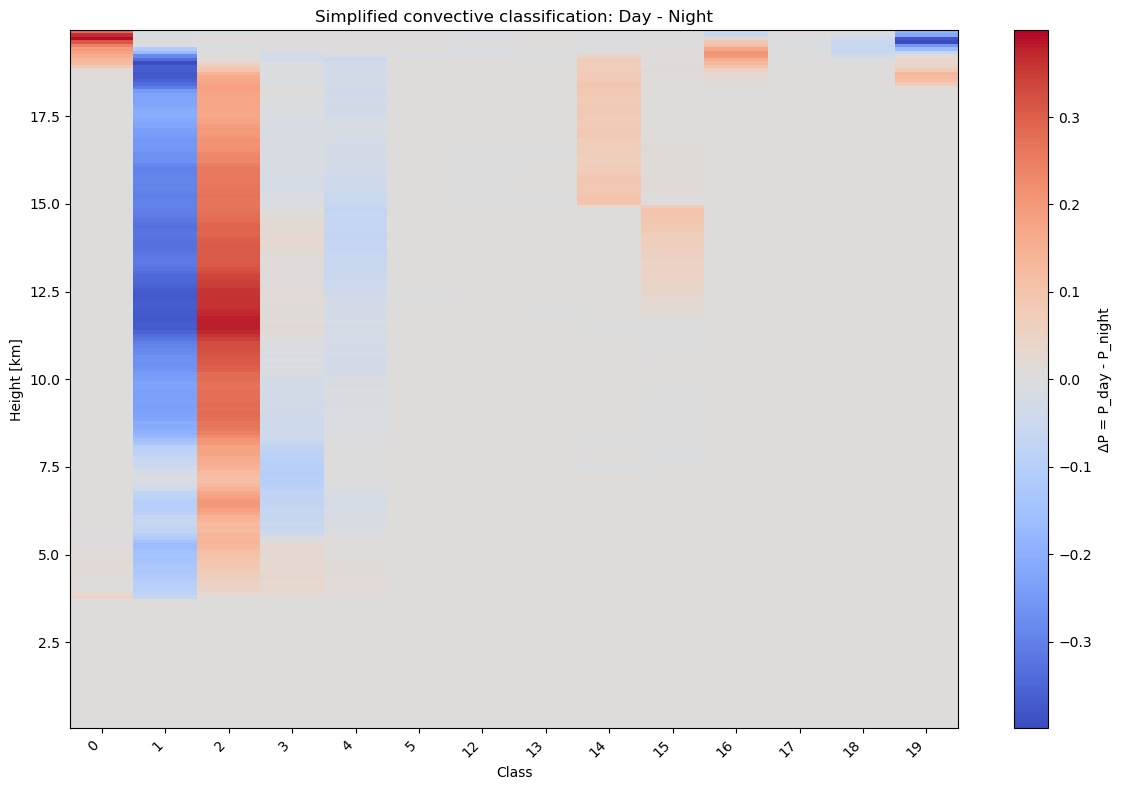

In [44]:
def plot_day_minus_night(day_stats, night_stats, class_map, title="Day - Night"):
    day_probs = day_stats["probs"]
    night_probs = night_stats["probs"]

    diff = day_probs - night_probs

    fig, ax = plt.subplots(figsize=(12, 8))

    vmax = np.nanmax(np.abs(diff))
    im = ax.imshow(
        diff.T,
        aspect="auto",
        origin="lower",
        cmap="coolwarm",
        vmin=-vmax,
        vmax=vmax,
        extent=[
            -0.5,
            len(day_stats["class_values"]) - 0.5,
            day_stats["bin_centers"][0] / 1000,
            day_stats["bin_centers"][-1] / 1000,
        ],
    )

    ax.set_title(title)
    ax.set_xlabel("Class")
    ax.set_ylabel("Height [km]")
    ax.set_xticks(np.arange(len(day_stats["class_values"])))
    ax.set_xticklabels([str(c) for c in day_stats["class_values"]], rotation=45, ha="right")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("ΔP = P_day - P_night")

    plt.tight_layout()
    plt.show()


plot_day_minus_night(
    daynight_stats["day"],
    daynight_stats["night"],
    SCC_CLASS_MAP,
    title="Simplified convective classification: Day - Night"
)

### Multiple Scattering Status

In [18]:
day_probs, day_counts, day_totals, day_bin_centers, day_class_values = compute_class_height_probabilities(
    df,
    "multiple_scattering_status",
    MSS_CLASS_MAP
)
night_probs, night_counts, night_totals, night_bin_centers, night_class_values = compute_class_height_probabilities(
    nf,
    "multiple_scattering_status",
    MSS_CLASS_MAP
)
daynight_stats = {
    "day":{
        "probs": day_probs,
        "counts": day_counts,
        "totals": day_totals,
        "bin_centers": day_bin_centers,
        "class_values": day_class_values
            },
    "night":{
        "probs": night_probs,
        "counts": night_counts,
        "totals": night_totals,
        "bin_centers": night_bin_centers,
        "class_values": night_class_values
            }
}
plot_class_height_heatmap(
    daynight_stats["day"]["probs"],
    daynight_stats["day"]["class_values"],
    daynight_stats["day"]["bin_centers"],
    MSS_CLASS_MAP,
    title="Day: multiple_scattering_status",
    save_dir = "stats_plots/day_multiple_scattering_status_hm.png"
)

plot_class_height_heatmap(
    daynight_stats["night"]["probs"],
    daynight_stats["night"]["class_values"],
    daynight_stats["night"]["bin_centers"],
    MSS_CLASS_MAP,
    title="Night: multiple_scattering_status",
    save_dir = "stats_plots/night_multiple_scattering_status_hm.png"
)

## Numerical values

In [14]:
def compute_mean_std_profile(file_paths, var_name, mode="whole", restrict_to_lightning_patches=True):
    profiles = []

    for fp in file_paths:
        with xr.open_dataset(fp) as ds:
            arr = ds[var_name].transpose("along_track", "height").values.astype(np.float32)

            y = ds["lightning_count_2p5"].values
            lightning_mask = np.isfinite(y) & (y != 0)
            has_lightning = np.any(lightning_mask)

            if restrict_to_lightning_patches and not has_lightning:
                continue

            if mode == "lightning":
                if not has_lightning:
                    continue
                arr = arr[lightning_mask, :]
            elif mode == "whole":
                pass

            if arr.size == 0 or np.all(np.isnan(arr)):
                continue

            
            prof = np.nanmean(arr, axis=0)
            profiles.append(prof)

    profiles = np.stack(profiles, axis=0)  # 

    mean_profile = np.nanmean(profiles, axis=0)
    std_profile = np.nanstd(profiles, axis=0)

    with xr.open_dataset(file_paths[0]) as ds0:
        heights = ds0["height"].values.astype(float)

    return mean_profile, std_profile, heights


def plot_lightning_vs_whole(file_paths, var_name, save_file=None):
    whole_mean, whole_std, heights = compute_mean_std_profile(
        file_paths, var_name, mode="whole", restrict_to_lightning_patches=True
    )
    ltg_mean, ltg_std, _ = compute_mean_std_profile(
        file_paths, var_name, mode="lightning", restrict_to_lightning_patches=True
    )

    y = heights / 1000.0

    plt.figure(figsize=(8, 8))

    plt.plot(whole_mean, y, label="Whole patch")
    plt.fill_betweenx(y, whole_mean - whole_std, whole_mean + whole_std, alpha=0.25)

    plt.plot(ltg_mean, y, label="Lightning pixels only")
    plt.fill_betweenx(y, ltg_mean - ltg_std, ltg_mean + ltg_std, alpha=0.25)

    plt.xlabel(var_name)
    plt.ylabel("Height [km]")
    plt.title(f"{var_name}: whole patch vs lightning-only")
    plt.legend()
    plt.grid(True, alpha=0.3)

    if save_file is None:
        plt.show()
    else:
        plt.savefig(save_file, dpi=200, bbox_inches="tight")
        plt.close()

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

dataset_path = "earthcare_patches"
dataset_path = Path(dataset_path)
all_files = sorted(str(f) for f in dataset_path.iterdir() if f.suffix == ".h5")

plot_lightning_vs_whole(all_files, "reflectivity_no_attenuation_correction", save_file = "stats_plots/reflectivity_no_attenuation_correction_compare.png")
plot_lightning_vs_whole(all_files, "doppler_velocity_best_estimate", save_file = "stats_plots/doppler_velocity_best_estimate_compare.png")
plot_lightning_vs_whole(all_files, "ice_water_content", save_file = "stats_plots/ice_water_content_compare.png")

/tmp/ipykernel_76/3046006792.py:30: RuntimeWarning: Mean of empty slice
  prof = np.nanmean(arr, axis=0)
/tmp/ipykernel_76/3046006792.py:30: RuntimeWarning: Mean of empty slice
  prof = np.nanmean(arr, axis=0)
/tmp/ipykernel_76/3046006792.py:30: RuntimeWarning: Mean of empty slice
  prof = np.nanmean(arr, axis=0)
/tmp/ipykernel_76/3046006792.py:30: RuntimeWarning: Mean of empty slice
  prof = np.nanmean(arr, axis=0)
/tmp/ipykernel_76/3046006792.py:30: RuntimeWarning: Mean of empty slice
  prof = np.nanmean(arr, axis=0)
/tmp/ipykernel_76/3046006792.py:30: RuntimeWarning: Mean of empty slice
  prof = np.nanmean(arr, axis=0)
/tmp/ipykernel_76/3046006792.py:30: RuntimeWarning: Mean of empty slice
  prof = np.nanmean(arr, axis=0)
/tmp/ipykernel_76/3046006792.py:30: RuntimeWarning: Mean of empty slice
  prof = np.nanmean(arr, axis=0)
/tmp/ipykernel_76/3046006792.py:30: RuntimeWarning: Mean of empty slice
  prof = np.nanmean(arr, axis=0)
/tmp/ipykernel_76/3046006792.py:30: RuntimeWarning: Mea

## Flag for lightning pixels

In [51]:
ds = xr.open_dataset("../scripts/dataset/earthcare_06346D_GLM_22.h5")
ds

<xarray.Dataset> Size: 5MB
Dimensions:                                 (along_track: 256, height: 200)
Coordinates:
  * along_track                             (along_track) int64 2kB 3696 ... ...
    time                                    (along_track) datetime64[ns] 2kB ...
    latitude                                (along_track) float64 2kB ...
    longitude                               (along_track) float64 2kB ...
  * height                                  (height) float64 2kB 50.0 ... 1.9...
Data variables: (12/22)
    lightning_count_2p5                     (along_track) uint32 1kB ...
    lightning_count_5                       (along_track) uint32 1kB ...
    ice_water_content                       (along_track, height) float32 205kB ...
    ice_mass_flux                           (along_track, height) float32 205kB ...
    ice_effective_radius                    (along_track, height) float32 205kB ...
    ice_median_volume_diameter              (along_track, height) float32 205kB ...
    ...                                      ...
    sedimentation_velocity_best_estimate    (along_track, height) float32 205kB ...
    spectrum_width_integrated               (along_track, height) float32 205kB ...
    reflectivity_no_attenuation_correction  (along_track, height) float32 205kB ...
    reflectivity_corrected                  (along_track, height) float32 205kB ...
    multiple_scattering_status              (along_track, height) float64 410kB ...
    simplified_convective_classification    (along_track, height) float64 410kB ...

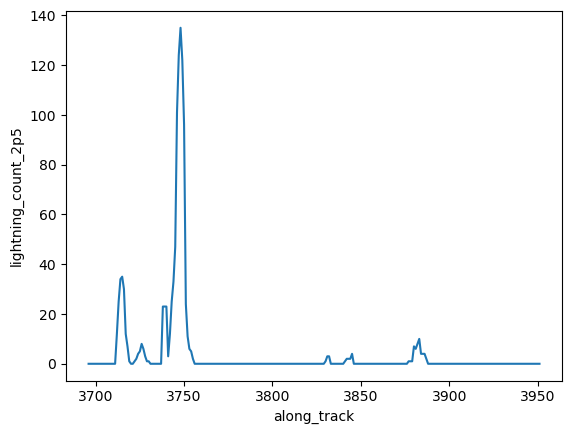

In [52]:
ds.lightning_count_2p5.T.plot()

In [57]:
ds.lightning_count_2p5.values

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,  12,  25,  34,  35,  30,  12,   7,   1,   0,   0,
         1,   2,   4,   5,   8,   6,   3,   1,   1,   0,   0,   0,   0,
         0,   0,   0,  23,  23,  23,   3,  12,  25,  33,  47, 101, 124,
       135, 122,  96,  24,  11,   6,   5,   2,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   1,   3,   3,   0,   0,   0,   0,   0,   0,
         0,   0,   1,   2,   2,   2,   4,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [62]:
arr = ds.lightning_count_2p5.values
lightning_mask = arr != 0
lightning_mask

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
        True,  True,  True,  True,  True,  True, False, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
       False, False, False, False, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,